In [87]:
from pathlib import Path

import numpy as np
import pypulseq as pp
from bmc.utils.seq.write import write_seq

import matplotlib.pyplot as plt

In [88]:
wdir = Path().resolve().parent
folder = wdir / "seq_lib"

sys = pp.Opts(
    max_grad=500,
    grad_unit="mT/m",
    max_slew=1e9,
    slew_unit="T/m/s",
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)
# general settings
AUTHOR = "DANIEL MIKSCH"
FLAG_PLOT_SEQUENCE = True  # plot preparation block?
FLAG_CHECK_TIMING = True  # perform a timing check at the end of the sequence?
FLAG_POST_PREP_SPOIL = True  # add spoiler after preparation block?

defs: dict = {}

### Definitions

In [89]:
seqid = "custom_ETM_minus" #file name

defs["a"] = 90 # alpha in degrees
defs["b0"] = 17  # B0 [T]
defs["m0_offset"] = -8  # m0 offset [ppm]
defs["n_ETM"] = 1  # number of ETMs

#rf settings
flip_angle_90 = np.radians(defs['a'])
flip_angle_180 = np.radians(180)
t_pulse = 2e-3 

#gradient settings
spoil_amp = 0.05222 * sys.max_grad  # Hz/m
# spoil_amp = 0.10 * sys.max_grad  # Hz/m
# spoil_amp = 0.15 * sys.max_grad  # Hz/m

crush_amp = 0.218 * sys.max_grad  # Hz/m
# crush_amp = 0.05 * sys.max_grad  # Hz/m

rise_time = 0.05e-3 #(spoil_amp / GAMMA_HZ) / sys.max_slew  # spoiler rise time in seconds
spoil_dur = 0.5e-3  # complete spoiler duration in seconds
exchange_dur = 80e-3
rephase_dur = 0.5e-3

#delay settings
delay_inter_etm = pp.make_delay(20e-3)
delay_exchange = pp.make_delay(80e-3)

pseudo_delay = pp.make_delay(1e-3)

#adc
pseudo_adc = pp.make_adc(num_samples=1, duration=1e-3)


In [90]:
defs["offsets_ppm"] = np.array([defs["m0_offset"]])
defs["num_meas"] = defs["offsets_ppm"].size  # number of repetition
defs["seq_id_string"] = seqid  # unique seq id
seq_filename = defs["seq_id_string"] + ".seq"
GAMMA_HZ = sys.gamma * 1e-6
defs["freq"] = defs["b0"] * GAMMA_HZ  # Larmor frequency [Hz]

### RF events

In [91]:
rf_90 = pp.make_gauss_pulse(
    flip_angle=flip_angle_90,
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

rf_90_re = pp.make_gauss_pulse(
    flip_angle=flip_angle_90,
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=np.radians(180),
    return_gz=False)

rf_90_water = pp.make_gauss_pulse(
    flip_angle=np.radians(90),
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

rf_180 = pp.make_gauss_pulse(
    flip_angle=flip_angle_180,
    system=sys,
    duration=t_pulse,
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

### Gradient events

In [92]:
# def create_trapezoid(amplitude, duration, rise_time, dt=sys.grad_raster_time):
#     if 2 * rise_time > duration:
#         raise ValueError("Die Anstiegs- und Abfallzeit zusammen dürfen nicht länger als die Gesamtdauer sein.")

#     # Anzahl der Samples für jede Phase
#     num_rise_samples = int(rise_time / dt)  # Anzahl der Samples für die Anstiegsphase
#     num_flat_samples = int((duration - 2 * rise_time) / dt)  # Anzahl der Samples für das Plateau
#     total_samples = num_rise_samples * 2 + num_flat_samples  # Gesamte Anzahl der Samples

#     # Trapezoid erstellen
#     trapezoid = np.zeros(total_samples)

#     # Anstiegsphase: Linear von 0 bis zur Amplitude
#     rise = np.linspace(0, amplitude, num_rise_samples, endpoint=False)
#     trapezoid[:num_rise_samples] = rise

#     # Plateau: Konstante Amplitude
#     trapezoid[num_rise_samples:num_rise_samples + num_flat_samples] = amplitude

#     # Abfallphase: Linear von Amplitude zurück auf 0
#     fall = np.linspace(amplitude, 0, num_rise_samples, endpoint=True)
#     trapezoid[num_rise_samples + num_flat_samples:] = fall

#     return trapezoid

In [93]:
def create_trapezoid(amplitude, duration, rise_time, total_length, dt=sys.grad_raster_time):
    """
    Erzeugt einen trapezförmigen Gradientimpuls, der in ein
    Array der Länge `total_length` (in Sekunden) zentriert wird.
    Alle Werte, die 0 ergeben, werden auf 3 gesetzt.
    
    Parameters:
    -----------
    amplitude : float
        Maximale Amplitude des Impulses.
    duration : float
        Dauer des Impulses (in Sekunden).
    rise_time : float
        Dauer der Anstiegs-/Abfallphase (in Sekunden).
    dt : float
        Zeitauflösung (in Sekunden).
    total_length : float
        Gesamtdauer des Rückgabevektors (in Sekunden).
        
    Returns:
    --------
    numpy.ndarray
        Array der Länge total_length/dt, in dem der Gradientimpuls mittig liegt,
        und alle 0-Werte durch 3 ersetzt wurden.
    """
    import numpy as np

    total_samples = int(round(total_length / dt))
    num_rise_samples = int(rise_time / dt)
    num_flat_samples = int((duration - 2 * rise_time) / dt)
    pulse_samples = num_rise_samples * 2 + num_flat_samples

    if pulse_samples > total_samples:
        raise ValueError("Die Gesamtlänge muss länger als die Pulsdauer sein.")

    # Erstelle den trapezförmigen Impuls
    rise = np.linspace(0, amplitude, num_rise_samples, endpoint=False)
    plateau = amplitude * np.ones(num_flat_samples)
    fall = np.linspace(amplitude, 0, num_rise_samples, endpoint=True)
    pulse = np.concatenate([rise, plateau, fall])

    # Erstelle das Gesamtsignal mit Hintergrundwert 3
    signal = np.full(total_samples, 0)
    start = (total_samples - pulse_samples) // 2
    signal[start:start+pulse_samples] = pulse

    # Ersetze sämtliche Nullen im Signal durch 3
    # signal[signal == 0] = 3

    return signal

In [94]:
#!/usr/bin/env python
# filepath: vscode-notebook-cell:/Users/danielmiksch/JupyterLab/optim/seq_init/custom_ETM.ipynb
import math
import numpy as np
from types import SimpleNamespace
from warnings import warn
from copy import copy
from typing import Union

# Angenommen, pypulseq.opts.Opts wird so importiert:
from pypulseq.opts import Opts
from pypulseq.supported_labels_rf_use import get_supported_rf_uses

def __gauss(x: np.ndarray) -> np.ndarray:
    return np.exp(-np.pi * np.square(x))

def make_double_gauss_pulse(
    flip_angle: float,
    apodization: float = 0,
    bandwidth: float = 0,
    center_pos: float = 0.5,
    delay: float = 0,
    dwell: float = 0,
    duration: float = 4e-3,
    gap: float = 1e-3,
    freq_offset: float = 0,
    phase_offset: float = 0,
    time_bw_product: float = 4,
    use: str = "",
    system: Union[Opts, None] = None,
    dead_time: float = 0,
    ringdown_time: float = 0
) -> SimpleNamespace:
    """
    Erzeugt ein Doppelpulspaar aus zwei Gauss-Pulsen à la make_gauss_pulse, wobei zwischen den Pulsen 
    eine Lücke (gap) eingefügt wird, die mit dem letzten Wert des ersten Pulses gefüllt wird.
    
    Die Parameter system, dwell, dead_time und ringdown_time werden analog zur Originalfunktion verwendet.
    
    Returns:
    --------
    rf : SimpleNamespace
        RF-Objekt mit den folgenden Feldern:
         - type: 'rf'
         - signal: Der Amplitudenarray (Doppelpuls mit Gap)
         - t: Zeitvektor passend zur Gesamtdauer des Signals
         - shape_dur: Gesamtdauer (Signaldauer)
         - freq_offset, phase_offset, delay, dead_time, ringdown_time und use (falls gesetzt)
    """
    # System setzen, falls nicht übergeben
    if system is None:
        system = Opts.default

    # Prüfe use, falls gesetzt
    if use != "" and use not in get_supported_rf_uses():
        raise ValueError(f"Invalid use parameter. Must be one of {get_supported_rf_uses()}. Passed: {use}")

    # Falls dwell nicht gesetzt, verwende den system.rf_raster_time
    if dwell == 0:
        dwell = system.rf_raster_time

    # Bandwidth setzen, falls nicht übergeben
    if bandwidth == 0:
        bandwidth = time_bw_product / duration

    # Anzahl Samples für einen einzelnen Gauss-Puls
    n_samples = int(round(duration / dwell))
    t_single = (np.arange(1, n_samples + 1) - 0.5) * dwell
    tt_single = t_single - (duration * center_pos)
    
    # Fensterfunktion
    window = 1 - apodization + apodization * np.cos(2 * np.pi * tt_single / duration)
    signal_single = window * __gauss(bandwidth * tt_single)
    
    # Normierungsfaktor: Fläche unter dem Puls (multipliziert mit 2*pi)
    flip_calc = np.sum(signal_single) * dwell * 2 * np.pi
    signal_single = signal_single * flip_angle / flip_calc

    # Erzeuge das Gap: Berechne Anzahl Samples für gap und fülle es mit dem letzten Wert des ersten Pulses.
    n_gap = int(round(gap / dwell))
    # gap_array = np.full(n_gap, signal_single[-1])
    gap_array = np.full(n_gap, 0)
   
    
    # Erstelle finalen Amplitudenarray: erster Puls, dann Gap, dann zweiter Puls (gleicher Gauss-Puls)
    double_signal = np.concatenate([signal_single, gap_array, signal_single])
    
    # Erstelle Zeitvektor entsprechend
    t_gap = t_single[-1] + dwell + np.arange(n_gap) * dwell
    t_second = t_single + (t_gap[-1] + dwell)
    t_double = np.concatenate([t_single, t_gap, t_second])
    
    rf = SimpleNamespace()
    rf.type = 'rf'
    rf.signal = double_signal
    rf.t = t_double
    rf.shape_dur = double_signal.size * dwell
    rf.freq_offset = freq_offset
    rf.phase_offset = phase_offset
    rf.delay = delay
    rf.dead_time = dead_time
    rf.ringdown_time = ringdown_time
    if use != "":
        rf.use = use

    if rf.dead_time > rf.delay:
        warn(
            f"Specified RF delay {rf.delay*1e6:.2f} µs is less than the dead time {rf.dead_time*1e6:.0f} µs. "
            f"Delay was increased to the dead time.",
            stacklevel=2
        )
        rf.delay = rf.dead_time

    # Workaround für negative Nullen, analog zum Original:
    negative_zero_indices = np.where(rf.signal == -0.0)
    rf.signal[negative_zero_indices] = 0

    return rf

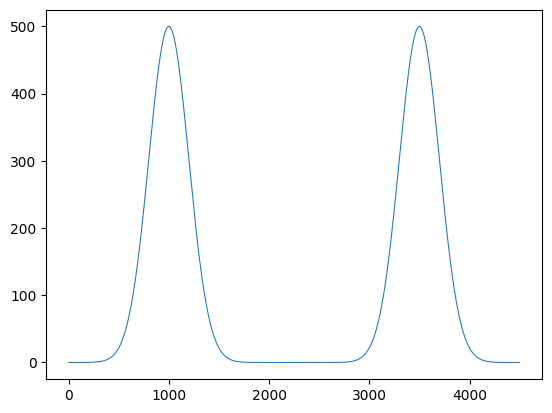

In [95]:
rf_90_double = make_double_gauss_pulse(
    flip_angle=np.radians(90),
    # flip_angle=np.radians(89.99984109),
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    gap=0.5e-3,
    system=sys,
    freq_offset=0,
    phase_offset=0)

rf_90_double_water = make_double_gauss_pulse(
    flip_angle=np.radians(90),
    # flip_angle=np.radians(89.99984109),
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    gap=0.5e-3,
    system=sys,
    freq_offset=0,
    phase_offset=0)

plt.plot(rf_90_double.signal)
len(rf_90_double.signal)
indices = np.where(rf_90_double.signal == 0)[0]


In [96]:
trapeziod_spoil = create_trapezoid(spoil_amp, spoil_dur, rise_time, total_length=4.5e-3)
trapeziod_rephase = create_trapezoid(spoil_amp, rephase_dur, rise_time, total_length=rephase_dur)
# trapeziod_spoil_minus = create_trapezoid(-spoil_amp, spoil_dur, rise_time)
trapeziod_exchange = create_trapezoid(crush_amp, exchange_dur, rise_time, total_length=exchange_dur)

gz_spoil = pp.make_arbitrary_grad(channel='z', 
                             system=sys, 
                             waveform=trapeziod_spoil,
                             first=0,
                             last=0
                             )
gz_rephase = pp.make_arbitrary_grad(channel='z',
                                    system=sys,
                                    waveform=trapeziod_rephase,
                                    first=0,
                                    last=0
                                    )
gz_exchange = pp.make_arbitrary_grad(channel='z',
                                     system=sys,
                                     waveform=trapeziod_exchange,
                                     first=0,
                                     last=0
                                     )

gz_spoil.waveform

array([0, 0, 0, ..., 0, 0, 0], shape=(4500,))

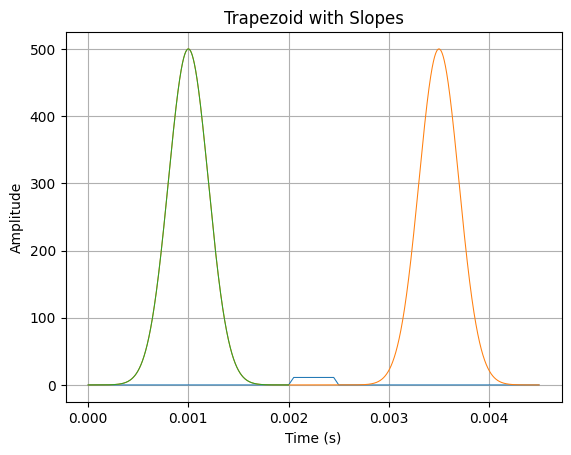

1111669.804

In [97]:
import matplotlib.pyplot as plt
# time = np.arange(len(rf_90_double.signal)) * dt  # Zeitachse
# time_rf = np.arange(len(rf_90.signal)) * dt  # Zeitachse
plt.plot(gz_spoil.tt, gz_spoil.waveform * 1e-5)
plt.plot(rf_90_double.t, rf_90_double.signal)
plt.plot(rf_90.t, rf_90.signal)
plt.title("Trapezoid with Slopes")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()
spoil_amp

### Sequence

In [98]:
seq = pp.Sequence()
offsets_hz = defs["offsets_ppm"] * defs["freq"]  # convert from ppm to Hz

In [99]:
rf_90_double

namespace(type='rf',
          signal=array([0.00176572, 0.00181061, 0.0018566 , ..., 0.0018566 , 0.00181061,
                        0.00176572], shape=(4500,)),
          t=array([5.000e-07, 1.500e-06, 2.500e-06, ..., 4.498e-03, 4.499e-03,
                   4.500e-03], shape=(4500,)),
          shape_dur=0.0045,
          freq_offset=0,
          phase_offset=0,
          delay=0,
          dead_time=0,
          ringdown_time=0)

In [100]:

rf_90.freq_offset = offsets_hz[0]
rf_90_double.freq_offset = offsets_hz[0]
# rf_90_double.phase_offset = np.radians(180)

print(rf_90_double.freq_offset)

for i in range(defs["n_ETM"]):
    seq.add_block(pseudo_delay)
    seq.add_block(rf_90_double, gz_spoil)
    seq.add_block(delay_exchange)
    
seq.add_block(rf_90_water)
seq.add_block(gz_rephase)
seq.add_block(pseudo_adc)


-5790.3904



Timing check passed successfully


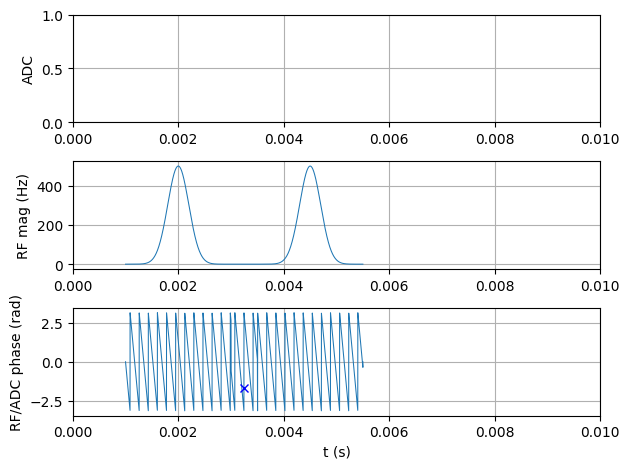

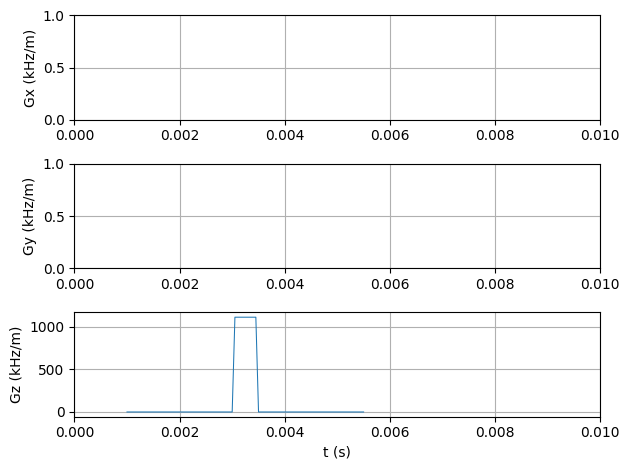

In [101]:
if FLAG_CHECK_TIMING:
    ok, error_report = seq.check_timing()
if ok:
    print("\nTiming check passed successfully")
else:
    print("\nTiming check failed! Error listing follows\n")
    print(error_report)

if FLAG_PLOT_SEQUENCE:
    seq.plot(time_range=[0.00, .01]) #time_range=[0.00, .03]

In [102]:
write_seq(seq=seq, seq_defs=defs, filename=folder / seq_filename, author=AUTHOR, use_matlab_names=True)

In [103]:
from bmc.utils.eval import calculate_flip_angle
import torch
pp.calc_rf_bandwidth(rf_90_double)
pp.calc_duration(rf_90_double)
t = rf_90_double.t[1] - rf_90_double.t[0]
calculate_flip_angle(torch.tensor(rf_90_double.signal), t)
# print(rf_90.signal)
# print(rf_90_double.signal)

180.00000000000006

In [ ]:
def plot(
        self,
        label: str = str(),
        show_blocks: bool = False,
        save: bool = False,
        time_range=(0, np.inf),
        time_disp: str = 's',
        grad_disp: str = 'kHz/m',
        plot_now: bool = True,
    ) -> None:
        """
        Plot `Sequence`.

        Parameters
        ----------
        label : str, default=str()
            Plot label values for ADC events: in this example for LIN and REP labels; other valid labes are accepted as
            a comma-separated list.
        save : bool, default=False
            Boolean flag indicating if plots should be saved. The two figures will be saved as JPG with numerical
            suffixes to the filename 'seq_plot'.
        show_blocks : bool, default=False
            Boolean flag to indicate if grid and tick labels at the block boundaries are to be plotted.
        time_range : iterable, default=(0, np.inf)
            Time range (x-axis limits) for plotting the sequence. Default is 0 to infinity (entire sequence).
        time_disp : str, default='s'
            Time display type, must be one of `s`, `ms` or `us`.
        grad_disp : str, default='s'
            Gradient display unit, must be one of `kHz/m` or `mT/m`.
        plot_now : bool, default=True
            If true, function immediately shows the plots, blocking the rest of the code until plots are exited.
            If false, plots are shown when plt.show() is called. Useful if plots are to be modified.
        plot_type : str, default='Gradient'
            Gradients display type, must be one of either 'Gradient' or 'Kspace'.
        """
        mpl.rcParams['lines.linewidth'] = 0.75  # Set default Matplotlib linewidth

        valid_time_units = ['s', 'ms', 'us']
        valid_grad_units = ['kHz/m', 'mT/m']
        valid_labels = get_supported_labels()
        if not all(isinstance(x, (int, float)) for x in time_range) or len(time_range) != 2:
            raise ValueError('Invalid time range')
        if time_disp not in valid_time_units:
            raise ValueError('Unsupported time unit')

        if grad_disp not in valid_grad_units:
            raise ValueError('Unsupported gradient unit. Supported gradient units are: ' + str(valid_grad_units))

        fig1, fig2 = plt.figure(), plt.figure()
        sp11 = fig1.add_subplot(311)
        sp12 = fig1.add_subplot(312, sharex=sp11)
        sp13 = fig1.add_subplot(313, sharex=sp11)
        fig2_subplots = [
            fig2.add_subplot(311, sharex=sp11),
            fig2.add_subplot(312, sharex=sp11),
            fig2.add_subplot(313, sharex=sp11),
        ]

        t_factor_list = [1, 1e3, 1e6]
        t_factor = t_factor_list[valid_time_units.index(time_disp)]

        g_factor_list = [1e-3, 1e3 / self.system.gamma]
        g_factor = g_factor_list[valid_grad_units.index(grad_disp)]

        t0 = 0
        label_defined = False
        label_idx_to_plot = []
        label_legend_to_plot = []
        label_store = {}
        for i in range(len(valid_labels)):
            label_store[valid_labels[i]] = 0
            if valid_labels[i] in label.upper():
                label_idx_to_plot.append(i)
                label_legend_to_plot.append(valid_labels[i])

        if len(label_idx_to_plot) != 0:
            p = parula.main(len(label_idx_to_plot) + 1)
            label_colors_to_plot = p(np.arange(len(label_idx_to_plot)))
            cycler = mpl.cycler(color=label_colors_to_plot)
            sp11.set_prop_cycle(cycler)

        # Block timings
        block_edges = np.cumsum([0] + [x[1] for x in sorted(self.block_durations.items())])
        block_edges_in_range = block_edges[(block_edges >= time_range[0]) * (block_edges <= time_range[1])]
        if show_blocks:
            for sp in [sp11, sp12, sp13, *fig2_subplots]:
                sp.set_xticks(t_factor * block_edges_in_range)
                sp.set_xticklabels(sp.get_xticklabels(), rotation=90)

        for block_counter in self.block_events:
            block = self.get_block(block_counter)
            is_valid = time_range[0] <= t0 + self.block_durations[block_counter] and t0 <= time_range[1]
            if is_valid:
                if getattr(block, 'label', None) is not None:
                    for i in range(len(block.label)):
                        if block.label[i].type == 'labelinc':
                            label_store[block.label[i].label] += block.label[i].value
                        else:
                            label_store[block.label[i].label] = block.label[i].value
                    label_defined = True

                if getattr(block, 'adc', None) is not None:  # ADC
                    adc = block.adc
                    # From Pulseq: According to the information from Klaus Scheffler and indirectly from Siemens this
                    # is the present convention - the samples are shifted by 0.5 dwell
                    t = adc.delay + (np.arange(int(adc.num_samples)) + 0.5) * adc.dwell
                    sp11.plot(t_factor * (t0 + t), np.zeros(len(t)), 'rx')
                    sp13.plot(
                        t_factor * (t0 + t),
                        np.angle(np.exp(1j * adc.phase_offset) * np.exp(1j * 2 * np.pi * t * adc.freq_offset)),
                        'b.',
                        markersize=0.25,
                    )

                    if label_defined and len(label_idx_to_plot) != 0:
                        arr_label_store = list(label_store.values())
                        lbl_vals = np.take(arr_label_store, label_idx_to_plot)
                        t = t0 + adc.delay + (adc.num_samples - 1) / 2 * adc.dwell
                        _t = [t_factor * t] * len(lbl_vals)
                        # Plot each label individually to retrieve each corresponding Line2D object
                        p = itertools.chain.from_iterable(
                            [sp11.plot(__t, _lbl_vals, '.') for __t, _lbl_vals in zip(_t, lbl_vals)]
                        )
                        if len(label_legend_to_plot) != 0:
                            sp11.legend(p, label_legend_to_plot, loc='upper left')
                            label_legend_to_plot = []

                if getattr(block, 'rf', None) is not None:  # RF
                    rf = block.rf
                    tc, ic = calc_rf_center(rf)
                    time = rf.t
                    signal = rf.signal
                    if abs(signal[0]) != 0:
                        signal = np.concatenate(([0], signal))
                        time = np.concatenate(([time[0]], time))
                        ic += 1

                    if abs(signal[-1]) != 0:
                        signal = np.concatenate((signal, [0]))
                        time = np.concatenate((time, [time[-1]]))

                    sp12.plot(t_factor * (t0 + time + rf.delay), np.abs(signal))
                    sp13.plot(
                        t_factor * (t0 + time + rf.delay),
                        np.angle(
                            signal * np.exp(1j * rf.phase_offset) * np.exp(1j * 2 * math.pi * time * rf.freq_offset)
                        ),
                        t_factor * (t0 + tc + rf.delay),
                        np.angle(
                            signal[ic]
                            * np.exp(1j * rf.phase_offset)
                            * np.exp(1j * 2 * math.pi * time[ic] * rf.freq_offset)
                        ),
                        'xb',
                    )

                grad_channels = ['gx', 'gy', 'gz']
                for x in range(len(grad_channels)):  # Gradients
                    if getattr(block, grad_channels[x], None) is not None:
                        grad = getattr(block, grad_channels[x])
                        if grad.type == 'grad':
                            # We extend the shape by adding the first and the last points in an effort of making the
                            # display a bit less confusing...
                            time = grad.delay + np.array([0, *grad.tt, grad.shape_dur])
                            waveform = g_factor * np.array((grad.first, *grad.waveform, grad.last))
                        else:
                            time = np.array(
                                cumsum(
                                    0,
                                    grad.delay,
                                    grad.rise_time,
                                    grad.flat_time,
                                    grad.fall_time,
                                )
                            )
                            waveform = g_factor * grad.amplitude * np.array([0, 0, 1, 1, 0])
                        fig2_subplots[x].plot(t_factor * (t0 + time), waveform)
            t0 += self.block_durations[block_counter]

        grad_plot_labels = ['x', 'y', 'z']
        sp11.set_ylabel('ADC')
        sp12.set_ylabel('RF mag (Hz)')
        sp13.set_ylabel('RF/ADC phase (rad)')
        sp13.set_xlabel(f't ({time_disp})')
        for x in range(3):
            _label = grad_plot_labels[x]
            fig2_subplots[x].set_ylabel(f'G{_label} ({grad_disp})')
        fig2_subplots[-1].set_xlabel(f't ({time_disp})')

        # Setting display limits
        disp_range = t_factor * np.array([time_range[0], min(t0, time_range[1])])
        [x.set_xlim(disp_range) for x in [sp11, sp12, sp13, *fig2_subplots]]

        # Grid on
        for sp in [sp11, sp12, sp13, *fig2_subplots]:
            sp.grid()

        fig1.tight_layout()
        fig2.tight_layout()
        if save:
            fig1.savefig('seq_plot1.jpg')
            fig2.savefig('seq_plot2.jpg')

        if plot_now:
            plt.show()
